In [1]:

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Importing the file     
import kagglehub
path = kagglehub.dataset_download("lava18/google-play-store-apps")
df = pd.read_csv(os.path.join(path, "googleplaystore.csv"))

### Cleaning and Sorting

In [2]:
# Drop the known shifted row(category='1.9' where all columns are shifted)
df=df[df["Category"]!='1.9']
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10840 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  object 
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.2+ MB


In [3]:
#3 Remove duplicates 
df.drop_duplicates(inplace=True)
df.Price.unique()


array(['0', '$4.99', '$3.99', '$6.99', '$1.49', '$2.99', '$7.99', '$5.99',
       '$3.49', '$1.99', '$9.99', '$7.49', '$0.99', '$9.00', '$5.49',
       '$10.00', '$24.99', '$11.99', '$79.99', '$16.99', '$14.99',
       '$1.00', '$29.99', '$12.99', '$2.49', '$10.99', '$1.50', '$19.99',
       '$15.99', '$33.99', '$74.99', '$39.99', '$3.95', '$4.49', '$1.70',
       '$8.99', '$2.00', '$3.88', '$25.99', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$2.50',
       '$1.59', '$6.49', '$1.29', '$5.00', '$13.99', '$299.99', '$379.99',
       '$37.99', '$18.99', '$389.99', '$19.90', '$8.49', '$1.75',
       '$14.00', '$4.85', '$46.99', '$109.99', '$154.99', '$3.08',
       '$2.59', '$4.80', '$1.96', '$19.40', '$3.90', '$4.59', '$15.46',
       '$3.04', '$4.29', '$2.60', '$3.28', '$4.60', '$28.99', '$2.95',
       '$2.90', '$1.97', '$200.00', '$89.99', '$2.56', '$30.99', '$3.61',
       '$394.99', '$1.26', '$1.20', '$1.04'], dtype=object)

In [4]:
#4 Clean "Installs " (removing "+" and convert to numeric)
df['Installs']=df['Installs'].astype(str).str.replace('+','', regex=False).str.replace(',','',regex=False)
df['Installs']=pd.to_numeric(df["Installs"],errors='coerce')

In [5]:
#5 Clean 'Price (remove '$' , convert to float)
df['Price']=df['Price'].astype(str).str.replace('$','',regex=False)   
df["Price"]=pd.to_numeric(df["Price"],errors="coerce")


In [6]:
#6 Cleaning Review and Ratings
df["Rating"]=pd.to_numeric(df['Rating'],errors="coerce")
df["Reviews"]=pd.to_numeric(df["Reviews"],errors="coerce")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  int64  
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.1+ MB


In [8]:
# Standardize "Size" to Megabyte(float)
def clean_size(val):
    if isinstance(val,str):
        if "M" in val:
             return float(val.replace("M",""))
        elif "k"  in val:
            return float(val.replace("k",""))/1024
    return np.nan
df["Size_MB"]=df["Size"].apply(clean_size)    
df["Size_MB"]

0        19.0
1        14.0
2         8.7
3        25.0
4         2.8
         ... 
10836    53.0
10837     3.6
10838     9.5
10839     NaN
10840    19.0
Name: Size_MB, Length: 10357, dtype: float64

In [9]:
# Converting "last updated " to datetime formate
df["Last Updated"]=pd.to_datetime(df["Last Updated"],errors="coerce")
df["Last Updated"]


0       2018-01-07
1       2018-01-15
2       2018-08-01
3       2018-06-08
4       2018-06-20
           ...    
10836   2017-07-25
10837   2018-07-06
10838   2017-01-20
10839   2015-01-19
10840   2018-07-25
Name: Last Updated, Length: 10357, dtype: datetime64[ns]

In [10]:
# Text standardization
df["Category"]=df["Category"].str.strip().str.upper()
df["Type"]=df["Type"].str.strip()

In [11]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,50000000,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,100000,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8


In [12]:
print(f"Data Cleaning Completed ! Cleaned Shape : {df.shape}")
df.head(3)

Data Cleaning Completed ! Cleaned Shape : (10357, 14)


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,10000,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,500000,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,5000000,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7


In [13]:
print("="*60)
print("                  Basic Level Questions                    ")
print("="*60)

                  Basic Level Questions                    


### Basic Question

In [14]:
## Q1: Average Rating of Apps

avg_rating=df["Rating"].mean()
print(f"Average Rating of apps is {avg_rating: .2f} / 5.0")

Average Rating of apps is  4.19 / 5.0


In [15]:
# Q2: Number of Unique Categories
df.columns
unique_cat=df['Category'].nunique()
print(f"Num of Unique Category is {unique_cat}")


Num of Unique Category is 33



 App size Distrubution


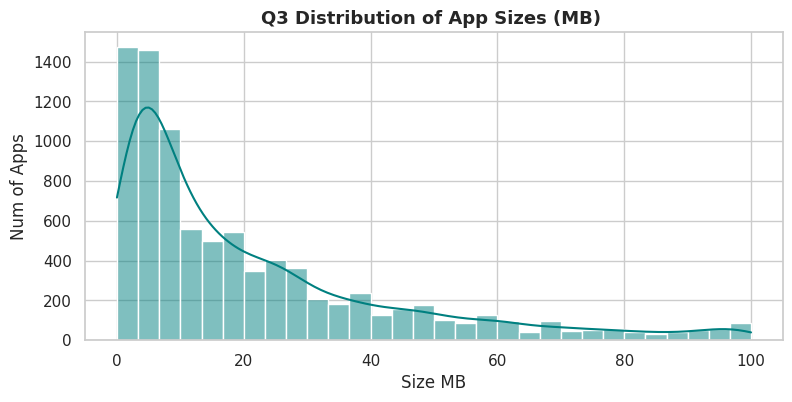

In [16]:
# Q3: Distribution of App Sizes (Histogram)
print("\n App size Distrubution")
plt.figure(figsize=(9,4))
sns.histplot(df["Size_MB"].dropna(),bins=30,kde=True,color="teal")
plt.title("Q3 Distribution of App Sizes (MB) ", fontsize=13, fontweight="bold")
plt.xlabel("Size MB")
plt.ylabel("Num of Apps")
plt.show()

In [17]:
# Q4: Free vs Paid Apps Count
print(" Free vs Paid App Breakdown")
print(df["Type"].value_counts(dropna=False).to_string())

 Free vs Paid App Breakdown
Type
Free    9591
Paid     765
NaN        1


In [18]:
# Q5: Most Common Content Rating (Mode)

common_content_rating=df["Content Rating"].mode()[0]
print(f"\n Most common content rating : {common_content_rating}")


 Most common content rating : Everyone


In [19]:
# Q6: Top 5 Most Installed Apps (Deduplicated by App name)
print("\n Most Installed Apps Name with category ")
top_5_installed= (
    df[["App","Installs","Category"]].sort_values(by="Installs",ascending=False)
    .drop_duplicates(subset="App").head(5)
)
print(top_5_installed.to_string(index=False))


 Most Installed Apps Name with category 
              App   Installs      Category
     Google Drive 1000000000  PRODUCTIVITY
Google Play Games 1000000000 ENTERTAINMENT
         Facebook 1000000000        SOCIAL
        Instagram 1000000000        SOCIAL
         Hangouts 1000000000 COMMUNICATION


In [20]:
# Q7: Apps with Rating >= 4.0
high_rated_count=(df["Rating"]>=4.0).sum()
total_rated=df["Rating"].dropna().count()
print(f"Apps with rating >4.0: {high_rated_count:,} ({(high_rated_count / total_rated) * 100 :.1f}% of rated apps)")

Apps with rating >4.0: 6,947 (78.1% of rated apps)


In [21]:
## Q8: Average Number of Reviews for Free vs Paid Apps
print("\nQ8. Average Reviews by App Type:")
print(df.groupby("Type")["Reviews"].mean().round(2).to_string())


Q8. Average Reviews by App Type:
Type
Free    437373.59
Paid     11900.55


In [22]:
# Q9: Average App Size per Category (Top 5 largest)
print("\nQ9. Average Size (MB) by Category (Top 5 Largest):")
df.columns
avg_size_by_cat=df.groupby("Category")["Size_MB"].mean().sort_values(ascending=False).head(5)
print(avg_size_by_cat.round(2).to_string())


Q9. Average Size (MB) by Category (Top 5 Largest):
Category
GAME                44.13
FAMILY              27.93
TRAVEL_AND_LOCAL    24.52
SPORTS              24.18
ENTERTAINMENT       22.64


In [23]:
# Q10: Apps Last Updated in 2018
updated_2018=(df["Last Updated"].dt.year == 2018).sum()
total_dated=df["Last Updated"].dropna().count()
print(f"Apps updated in 2018 : {updated_2018:,} ({(updated_2018/total_dated)*100:.1f} %) of dated inventory")

Apps updated in 2018 : 6,934 (66.9 %) of dated inventory


In [24]:
print("*"*65)
print("                Medium Question")
print("*"*65)

*****************************************************************
                Medium Question
*****************************************************************


## Medium Questions

In [25]:
# Q1: Correlation between Installs and Rating
corr_val=df[["Installs","Rating"]].dropna().corr().iloc[0,1]
print(f"Corrrelation (Install vs Ratings : {corr_val:.4f}")


Corrrelation (Install vs Ratings : 0.0509


> The correlation is near zero ($\approx 0.05$). High install volume does not guarantee high customer satisfaction; scale and sentiment operate independently.  

### **[Insights]** :
#### Near Zero correlation  indicates polularity does not guarantee high satisfaction.

In [26]:
# Q2: App categories with the highest average rating

cat_ratings=(
    df.groupby("Category")["Rating"].agg(["mean","count"]).sort_values(by="mean",ascending=False))
print("Top 5 categories with highest avg rating ")
print(cat_ratings.head(5).round(2).to_string())

Top 5 categories with highest avg rating 
                     mean  count
Category                        
EVENTS               4.44     45
EDUCATION            4.38    129
ART_AND_DESIGN       4.36     62
BOOKS_AND_REFERENCE  4.35    177
PERSONALIZATION      4.33    310


> Niche categories (like EVENTS or EDUCATION) often score higher averages than massive categories (TOOLS or COMMUNICATION), which face broader public scrutiny.

In [27]:
# Q3: Price vs Average Rating (Paid Apps Only)
# Business Impact: Informs optimal pricing tiers without hurting review quality

df.columns
df["Type"].unique()
paid_apps=df[(df["Type"]=="Paid") & (df["Price"]>0)].dropna(subset=["Rating","Price"])

#grouping into price bins for clear readability
price_bins=[0,2,5,10,50,500]
price_labels=["$0.01-$2","$2-$5","$5-$10","$10-$50","$50+"]
paid_apps["Price_Tier"]=pd.cut(paid_apps["Price"],bins=price_bins,labels=price_labels)

print("Impact of App Price on Average Rating(Paid app by Tier)")
print(paid_apps.groupby("Price_Tier",observed=False)["Rating"].agg(["mean","count"]).round(2).to_string())


Impact of App Price on Average Rating(Paid app by Tier)
            mean  count
Price_Tier             
$0.01-$2    4.30    208
$2-$5       4.26    287
$5-$10      4.24     61
$10-$50     4.23     41
$50+        3.91     16


> Apps priced between 1-5 dollars  retain solid ratings, but ratings decline sharply past dollars 50 where user expectations surge.

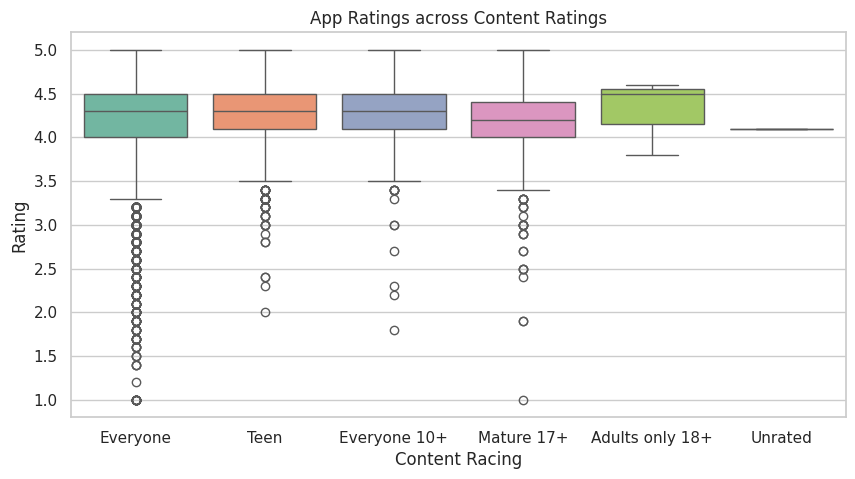

In [28]:
#Q4 distribution of app ratings across different content ratings?

sns.boxplot(
    data=df.dropna(subset=["Content Rating","Rating"]),
    x="Content Rating",
    y="Rating",
    palette="Set2",
    hue="Content Rating",
    legend=False
)
plt.title("App Ratings across Content Ratings", loc="center")
plt.xlabel("Content Racing")
plt.ylabel("Rating")
plt.show()


>  ratings are consistent ($\approx 4.2–4.3$) across target demographics, Everyone and Teen display a wide spread of low-rating outliers.

In [29]:
# Q5 Genres with the most apps having > 1 Million Installs
df.columns
high_installs= df[df["Installs"]>1000000]
top_genre=high_installs["Genres"].value_counts().head(5)
print("Top Genre with >1M installs : ")
print(top_genre.to_string())

Top Genre with >1M installs : 
Genres
Tools            187
Action           182
Photography      161
Communication    146
Productivity     124


In [30]:
# Q6: App Update Frequency (Average time between updates)
# Group repeated app entries by date to find delta between versions

app_versions=df.dropna(subset=["Last Updated"]).sort_values(["App","Last Updated"])
app_versions["Days_Between_Updated"]=app_versions.groupby("App")["Last Updated"].diff().dt.days

avg_days=app_versions["Days_Between_Updated"].dropna().mean()

if pd.isna(avg_days) or avg_days==0:
    # altternate metric : recency from the latest dataset data 
    latest_data =df["Last Updated"].max()
    avg_recency=(latest_date-df["Last Updated"]).dt.days.mean()
    print(f"Average Recency since last updates (relative to dataset peak): {avg_recency:.1f} days")

else:
    print(f"Q6. Average Time Between Recorded Consecutive Updates: {avg_days:.1f} days")
print("\nFrequent updates correlate directly with active retention and security patching.")



Q6. Average Time Between Recorded Consecutive Updates: 7.9 days

Frequent updates correlate directly with active retention and security patching.


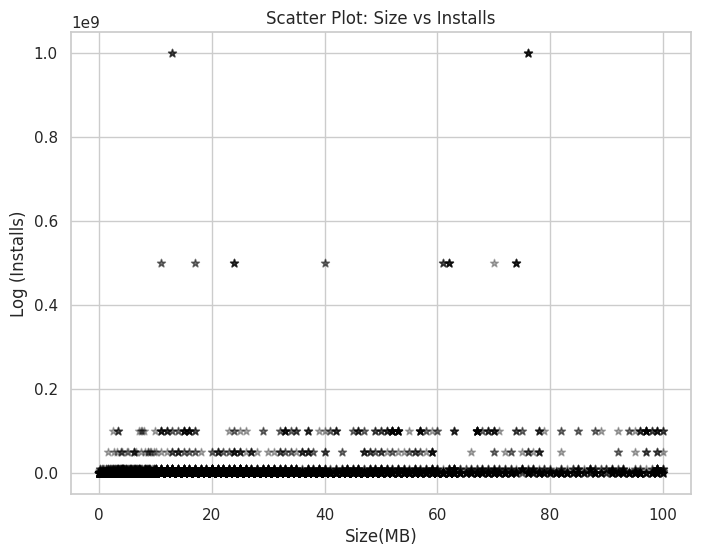

In [31]:
# Q7 Scatter Plot: Size vs Installs (Log Scale)
plt.figure(figsize=(8,6))
plt.scatter(
    data=df.dropna(subset=["Size_MB","Installs"]),
    x= "Size_MB",
    y= "Installs",
    alpha=0.3,
    color="black",
    marker="*"
)
plt.title("Scatter Plot: Size vs Installs")
plt.xlabel("Size(MB)")
plt.ylabel("Log (Installs)")
plt.show()

 > Confirms that while heavy apps (>50 MB) can still succeed, the $100\text{M}+$ download club consists primarily of compact, universally accessible apps

In [32]:
# -------------------------------------------------------------
# Q8: Top Reviewed Apps and their Ratings
# -------------------------------------------------------------

print("Top 5 Reviewed Apps and their Ratings:")
top_reviewed=(
    df[['App', 'Category', 'Rating', 'Reviews']]    # Taking in account ( all app category rating and review and sort by reviews as in descending order )
    .sort_values(by="Reviews" , ascending = False)  
    .drop_duplicates(subset="App")                   # drop duplicates to account for only single app 
    .head(5)
)
print(top_reviewed.to_string(index=False))
print()

Top 5 Reviewed Apps and their Ratings:
                                     App      Category  Rating  Reviews
                                Facebook        SOCIAL     4.1 78158306
                      WhatsApp Messenger COMMUNICATION     4.4 69119316
                               Instagram        SOCIAL     4.5 66577446
Messenger – Text and Video Chat for Free COMMUNICATION     4.0 56646578
                          Clash of Clans          GAME     4.6 44893888



In [33]:
# Q9: Content Rating Distribution: Free vs Paid
print("Crosstab: Content Rating vs App Type")

ct=pd.crosstab(df["Content Rating"],df["Type"], margins=True) # adding margin= True produce row/column marginal total and normali
print(ct.to_string())

# CrossTab / Cross Tabular : Two categorical columns and row and numerical values that falls true for both.

Crosstab: Content Rating vs App Type
Type             Free  Paid    All
Content Rating                    
Adults only 18+     3     0      3
Everyone         7720   662   8382
Everyone 10+      344    32    376
Mature 17+        428    19    447
Teen             1094    52   1146
Unrated             2     0      2
All              9591   765  10356


In [34]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB'],
      dtype='object')

In [35]:
# Q10: Top 5 Categories with the Most Installs (Pareto Concentration)
top_cat_installs=df.groupby("Category")["Installs"].sum().sort_values(ascending=False).head(5)
print("Top 5 Categories by Total Installs:")
print(top_cat_installs.apply(lambda x: f"{x:,.0f}").to_string())    

# .apply() apply (whatever in bracket to each series or dataframe)  
#   lambda( x: )    x- element of series/ dataframe line by line 
#      :, → Adds thousands separators (commas).
#   " .0f" → Formats as a fixed-point number with 0 decimal places.

# Handful of categories captures over 70% of total app store Traffic (30:70)


Top 5 Categories by Total Installs:
Category
GAME             31,544,024,415
COMMUNICATION    24,152,276,251
SOCIAL           12,513,867,902
PRODUCTIVITY     12,463,091,369
TOOLS            11,452,771,915


<function matplotlib.pyplot.show(close=None, block=None)>

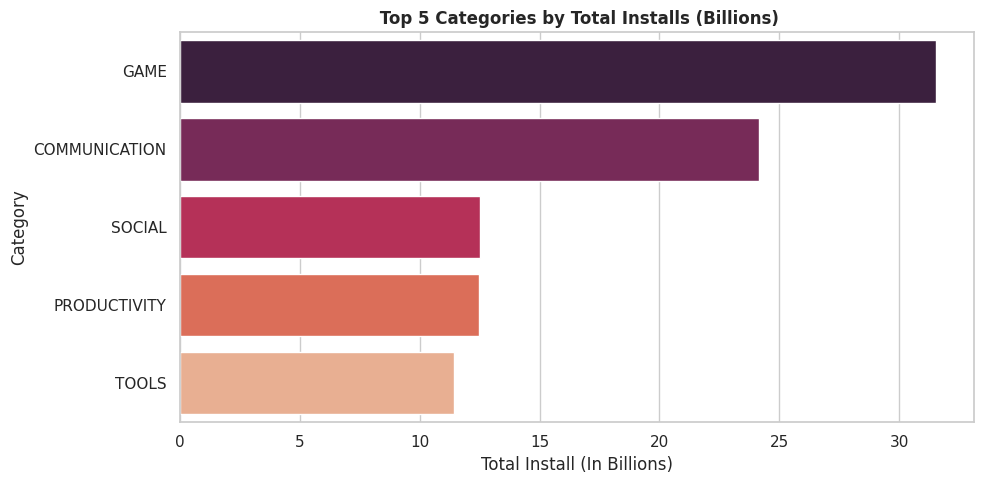

In [36]:
sns.barplot(
    x=top_cat_installs.values / 1e9,
    y=top_cat_installs.index,
    palette='rocket', 
    hue= top_cat_installs.index,   
    legend = False
)
# Setting the title and labels using plt 
plt.title(" Top 5 Categories by Total Installs (Billions)",fontweight="bold")
plt.xlabel("Total Install (In Billions)")

plt.tight_layout()
plt.show

In [37]:
print("=" * 70)
print("             ADVANCED-LEVEL QUESTIONS (Q1 - Q5)             ")
print("=" * 70)

             ADVANCED-LEVEL QUESTIONS (Q1 - Q5)             


In [38]:
# Q1: Top 10 Apps with the Highest Ratings & Their Reviews/Installs
perfect_apps=df[(df["Rating"]==5)].drop_duplicates(subset="App")
print(f"Total apps with a perfect 5.0 rating: {len(perfect_apps):,}")

# top 10 reviews among highest rating apps 
top_10_rated=(
    perfect_apps[["Category","App","Rating","Reviews","Installs"]].sort_values(by=["Reviews","Installs"],ascending=False).head(10)
)
print("\n Top 10 highest rated (5.0) Apps (Sorted by Reviews and Installs :)")
print(top_10_rated.to_string(index=False))
print("\nKey Insight: Most 5.0 apps have low install counts (<10k). High volume makes sustaining 5.0 stars statistically improbable.")

Total apps with a perfect 5.0 rating: 271

 Top 10 highest rated (5.0) Apps (Sorted by Reviews and Installs :)
          Category                                               App  Rating  Reviews  Installs
         LIFESTYLE                                        Ríos de Fe     5.0      141      1000
           FINANCE FD Calculator (EMI, SIP, RD & Loan Eligilibility)     5.0      104      1000
         LIFESTYLE                                        Oración CX     5.0      103      5000
            FAMILY                    Barisal University App-BU Face     5.0      100      1000
            FAMILY                                        Master E.K     5.0       90      1000
             TOOLS                                           CL REPL     5.0       47      1000
       PHOTOGRAPHY                                            AJ Cam     5.0       44       100
            FAMILY                       CS & IT Interview Questions     5.0       43      1000
      PRODUCTIVITY       

In [39]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver', 'Size_MB'],
      dtype='object')

Text(0.5, 0, 'Year-Month')

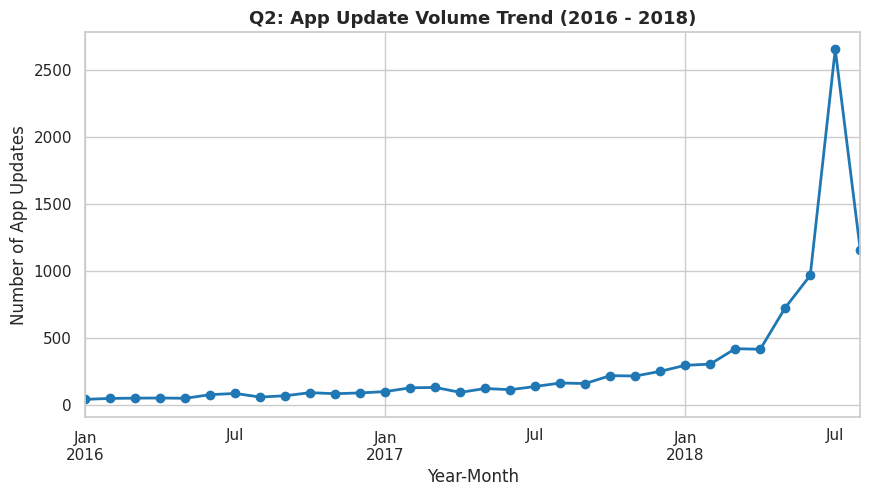

In [40]:
# (Q2): Trend of Apps Update over time & seasonality
df_dated=df.dropna(subset=["Last Updated"]).copy()
df_dated["Year_Month"]=df_dated["Last Updated"].dt.to_period("M")
df_dated["Month_name"]=df_dated["Last Updated"].dt.month_name()

# Updates over time (Monthly Trend)
monthly_updates = df_dated[df_dated['Last Updated'].dt.year >= 2016]['Year_Month'].value_counts().sort_index()
monthly_updates.plot(kind='line', color='#1f77b4', marker='o', lw=2)
plt.title('Q2: App Update Volume Trend (2016 - 2018)', fontsize=13, fontweight='bold')
plt.ylabel('Number of App Updates')
plt.xlabel('Year-Month')

In [42]:
# Advanced Question Binned Analysis (Rating vs Installs)
install_bins = [-1,100,10000,100000,1000000,10000000,1000000000]
install_labels=['<100', '100-10K', '10K-100K', '100K-1M', '1M-10M', '10M+']
df["Install_bins"]=pd.cut(df["Installs"],bins=install_bins,labels=install_labels)


Binned Analysis : Rating Progression across Install Tier
              mean  median   std  count
Install_bins                           
<100          4.42     4.8  0.88    440
100-10K       4.05     4.2  0.69   2312
10K-100K      4.09     4.2  0.50   1572
100K-1M       4.21     4.3  0.38   2002
1M-10M        4.29     4.3  0.30   1815
10M+          4.37     4.4  0.20    751


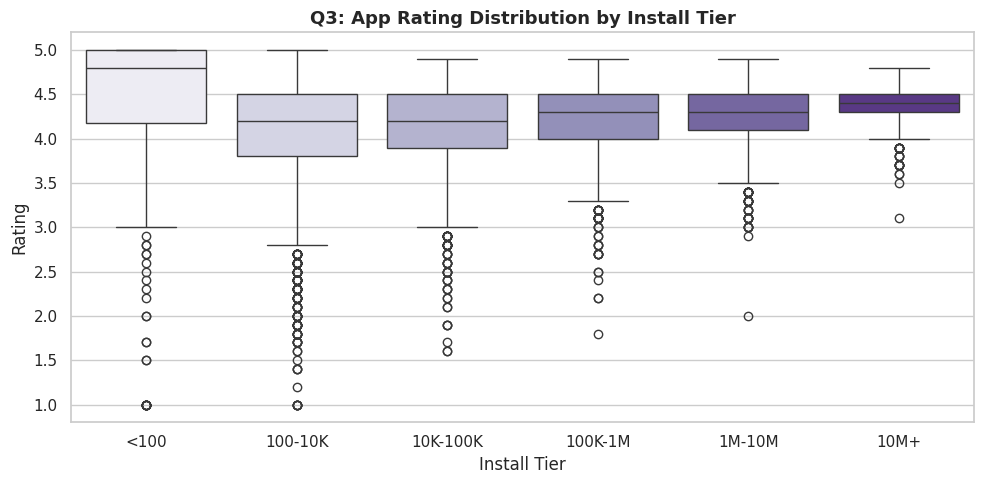

In [52]:
# Aggregate Rating Across each Install Bin
binned_summary=(
    df.groupby("Install_bins",observed=False)["Rating"].agg(["mean","median","std","count"]).round(2))
print("Binned Analysis : Rating Progression across Install Tier")
print(binned_summary.to_string())


plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df.dropna(subset=['Install_bins', 'Rating']),
    x='Install_bins',
    y='Rating',
    palette='Purples',
    hue="Install_bins",
    legend=False
)
plt.title('Q3: App Rating Distribution by Install Tier', fontsize=13, fontweight='bold')
plt.xlabel('Install Tier')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

In [46]:
print("Q4. Sentiment Analysis on App Reviews:")

reviews_path = None
for dirname, _, filenames in os.walk(path if 'path' in globals() else '/kaggle/input'):
    for filename in filenames:
        if 'user_reviews' in filename.lower() and filename.endswith('.csv'):
            reviews_path = os.path.join(dirname, filename)
            break

if reviews_path and os.path.exists(reviews_path):
    reviews_df = pd.read_csv(reviews_path)
    print(f"Loaded User Reviews from: {reviews_path}")
    sentiment_dist = reviews_df['Sentiment'].value_counts(normalize=True) * 100
    print("\nSentiment Distribution (%):")
    print(sentiment_dist.round(2).to_string())
    
    # Merge with app categories to see sentiment polarity by category
    merged_rev = reviews_df.dropna(subset=['Sentiment_Polarity']).merge(
        df[['App', 'Category']].drop_duplicates(), on='App', how='inner'
    )
    print("\nTop 5 Categories with Highest Positive Sentiment Polarity:")
    print(merged_rev.groupby('Category')['Sentiment_Polarity'].mean().sort_values(ascending=False).head(5).round(3).to_string())
else:
    print("User review text file not present. Using rating-based sentiment classification:")
    df['Review_Sentiment'] = pd.cut(
        df['Rating'], 
        bins=[0, 3.0, 4.0, 5.0], 
        labels=['Negative (<3.0)', 'Neutral (3.0-4.0)', 'Positive (4.0-5.0)']
    )
    print(df['Review_Sentiment'].value_counts(normalize=True).round(4) * 100)

Q4. Sentiment Analysis on App Reviews:
Loaded User Reviews from: /kaggle/input/datasets/lava18/google-play-store-apps/googleplaystore_user_reviews.csv

Sentiment Distribution (%):
Sentiment
Positive    64.11
Negative    22.10
Neutral     13.79

Top 5 Categories with Highest Positive Sentiment Polarity:
Category
COMICS               0.440
EVENTS               0.378
AUTO_AND_VEHICLES    0.349
PARENTING            0.319
WEATHER              0.295


In [47]:
# Q5: Relationship Between App Genre and User Ratings
# -----------------------------------------------------------------
# Focus on genres with at least 30 apps for statistical significance
genre_stats = (
    df.groupby('Genres')['Rating']
    .agg(['mean', 'median', 'std', 'count'])
    .query('count >= 30')
    .sort_values(by='mean', ascending=False)
)
print("\n" + "=" * 70)
print("Q5. Top 5 Consistently Highest Rated Genres (min 30 apps):")
print(genre_stats.head(5).round(2).to_string())

print("\nBottom 5 Lowest Rated Genres (min 30 apps):")
print(genre_stats.tail(5).round(2).to_string())
print("=" * 70)


Q5. Top 5 Consistently Highest Rated Genres (min 30 apps):
                     mean  median   std  count
Genres                                        
Events               4.44     4.5  0.42     45
Puzzle               4.39     4.4  0.34    117
Art & Design         4.36     4.4  0.36     56
Education;Education  4.35     4.4  0.40     44
Books & Reference    4.35     4.5  0.43    177

Bottom 5 Lowest Rated Genres (min 30 apps):
                         mean  median   std  count
Genres                                            
Video Players & Editors  4.06    4.20  0.55    158
Maps & Navigation        4.05    4.20  0.52    124
Tools                    4.05    4.20  0.62    733
Dating                   3.97    4.10  0.62    159
Educational              3.87    3.95  0.56     32


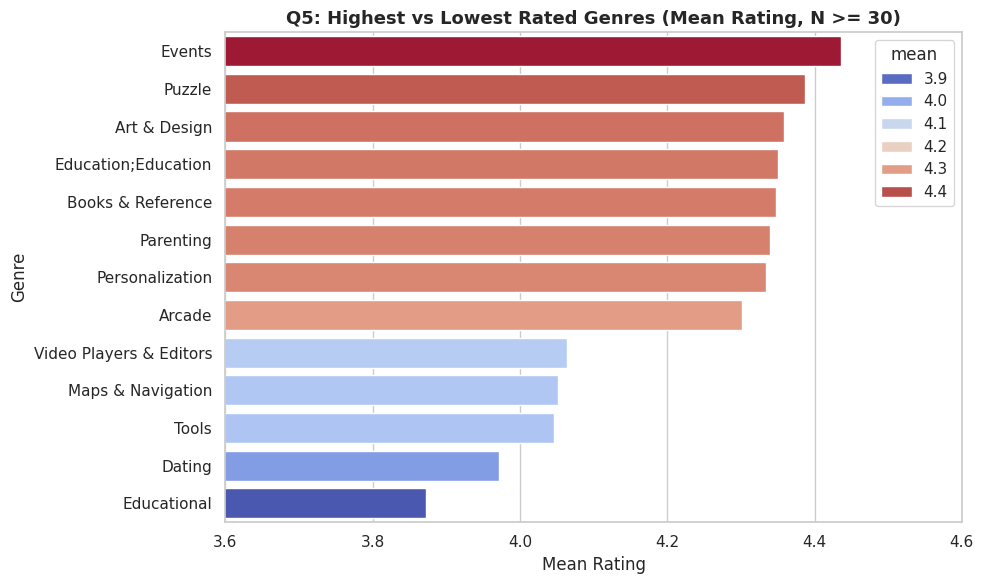

In [55]:
sam_genres = pd.concat([genre_stats.head(8), genre_stats.tail(5)])

plt.figure(figsize=(10, 6))
sns.barplot(
    x=sam_genres['mean'],
    y=sam_genres.index,
    palette='coolwarm',
    hue=sam_genres["mean"]
)
plt.xlim(3.6, 4.6)
plt.title('Q5: Highest vs Lowest Rated Genres (Mean Rating, N >= 30)', fontsize=13, fontweight='bold')
plt.xlabel('Mean Rating')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()